# British Airways - Customer Customer Buying Behavior Prediction
### Problem Statement
The goal of this project is to build a predictive model that identifies customers who are likely to complete a booking. By predicting high-intent customers earlier in the booking funnel, British Airways can optimize marketing allocation, personalize offers, and improve overall conversion rates. 

The target variable is `booking_complete`, a binary flag indicating whether the booking was finalized.

### Table of Contents
1. [Data Overview & Preparation](#1.-Data-Overview-&-Preparation)
2. [Exploratory Data Analysis](#2.-Exploratory-Data-Analysis)<br>
   2.1 [Feature Distributions](#2.1-Feature-Distributions)<br>
   2.2 [Target vs Feature Analysis](#2.2-Target-vs-Feature-Analysis)<br>
   2.3 [Numerical Binning Analysis](#2.3-Numerical-Binning-Analysis)<br>
   2.3 [Correlation Analysis](#2.4-Correlation-Analysis)<br>
3. [Feature Engineering](#3.-Feature-Engineering)<br>
4. [XGBoost Model](#4.-XGBoost-Model)<br>
5. [Model Evaluation](#5.-Model-Evaluation)<br>
6. [Business Insights & Conclusion](#6.-Business-Insights-&-Conclusion)<br>

## 1. Data Overview & Preparation
Importing necessary libraries, loading dataset, and getting summary statistics.

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import pickle

In [27]:
pd.set_option('display.max_columns', None)

In [28]:
df = pd.read_csv("../Forage-British Airways/customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [30]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [31]:
df.duplicated().sum()

719

Considering that different individuals may have identical search records, duplicates may be reasonable and should not be deleted for now.

#### Column Description

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

## 2. Exploratory Data Analysis

### 2.1 Feature Distributions
Understand variable distributions, detect skewness, imbalance, and potential transformation needs.

In [32]:
df1 = df.copy()

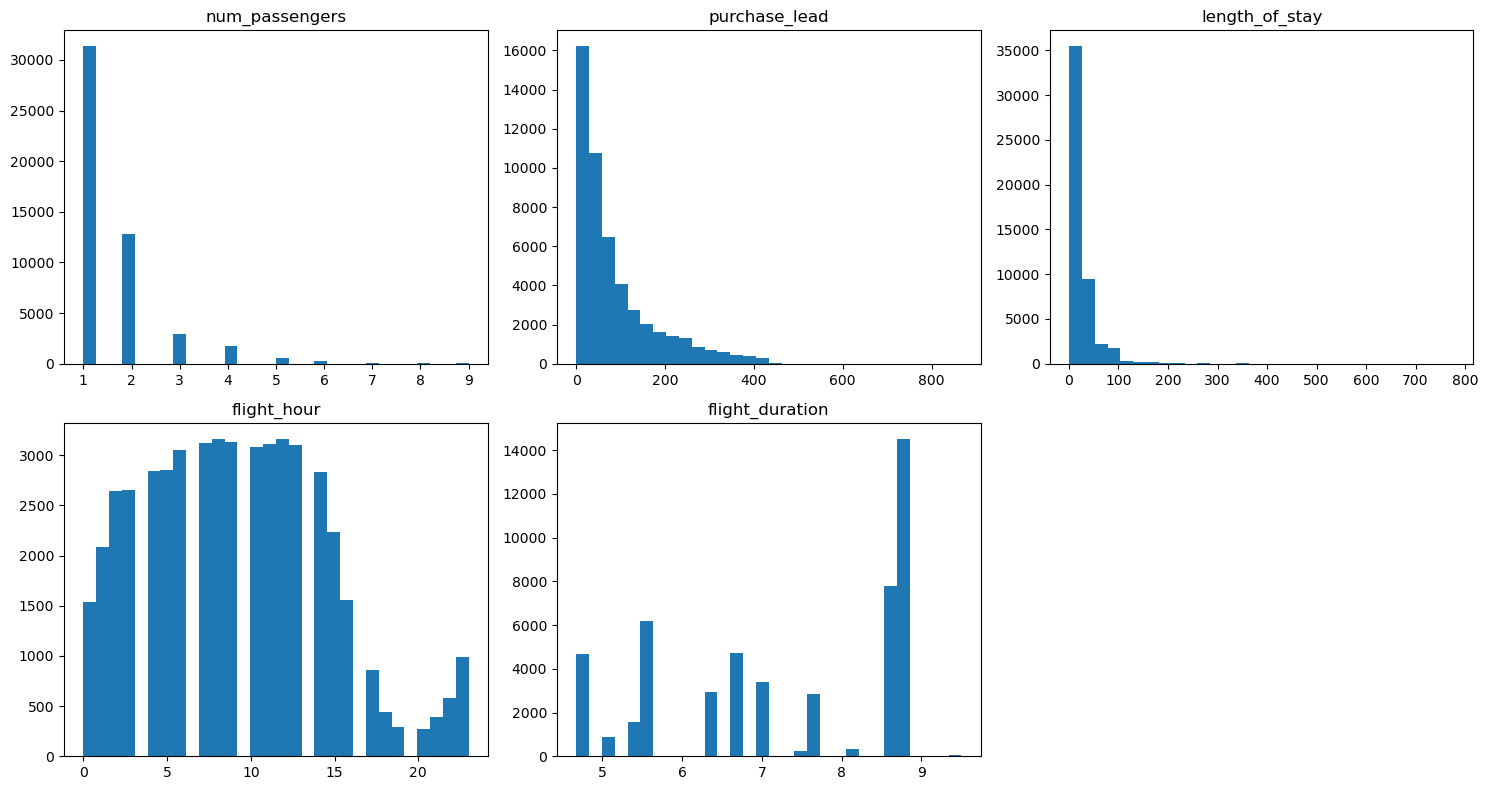

In [33]:
numeric_cols = ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df1[col], bins=30)
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

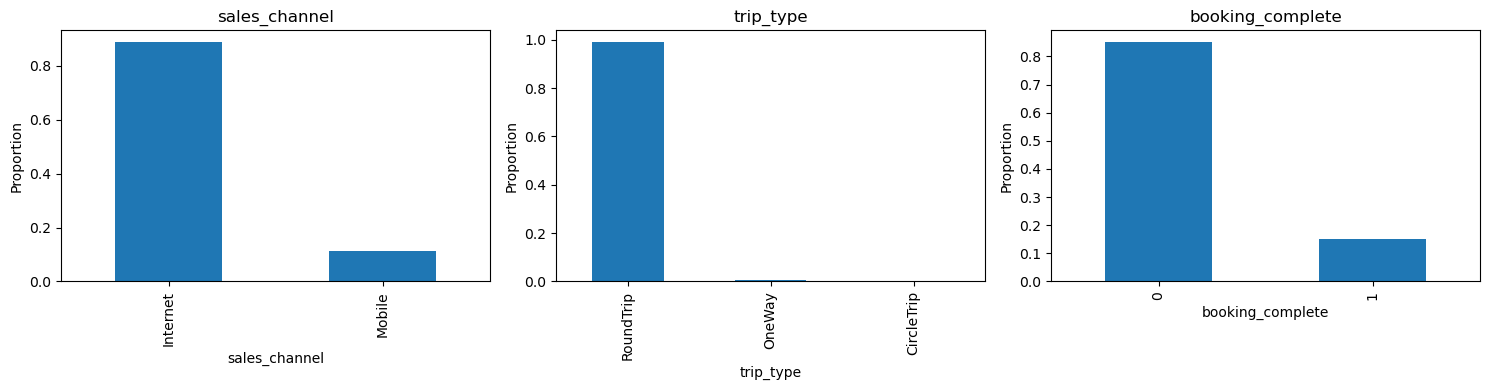

In [34]:
cat_cols = ['sales_channel', 'trip_type', 'booking_complete']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(15, 4))

for ax, col in zip(axes, cat_cols):
    (df1[col]
     .value_counts(normalize=True)
     .plot(kind='bar', ax=ax))
    
    ax.set_title(col)
    ax.set_ylabel('Proportion')

plt.tight_layout()
plt.show()

In [35]:
df1["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

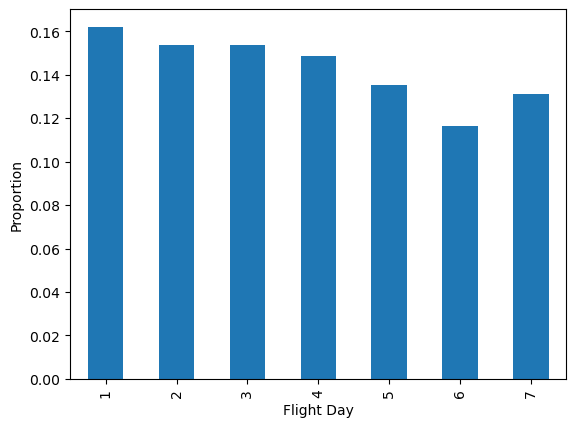

In [36]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df1["flight_day"] = df1["flight_day"].map(mapping)

flight_day = df1['flight_day'].value_counts(normalize=True).sort_index()
flight_day.plot(kind='bar')
plt.xlabel('Flight Day')
plt.ylabel('Proportion')
plt.show()

In [37]:
df1['route'].value_counts().describe()

count     799.000000
mean       62.578223
std       146.462227
min         1.000000
25%         5.000000
50%        18.000000
75%        56.500000
max      2680.000000
Name: count, dtype: float64

In [38]:
df1['booking_origin'].value_counts().describe()

count      104.000000
mean       480.769231
std       2001.980268
min          1.000000
25%          1.000000
50%          8.000000
75%         47.250000
max      17872.000000
Name: count, dtype: float64

#### Obeservations
- `purchase_lead` and `length_of_stay` are heavily right-skewed.
- `trip_type` is extremely imbalanced (≈99% RoundTrip).
- Target variable `booking_complete` is imbalanced (15% positive).
- `route` (799 categories) and `booking_origin` (104 categories) are high-cardinality features.

### 2.2 Target vs Feature Analysis
Evaluate predictive power by analyzing booking rates across discrete features.

In [39]:
def booking_rate(df, col):
    return df.groupby(col)['booking_complete'].mean()

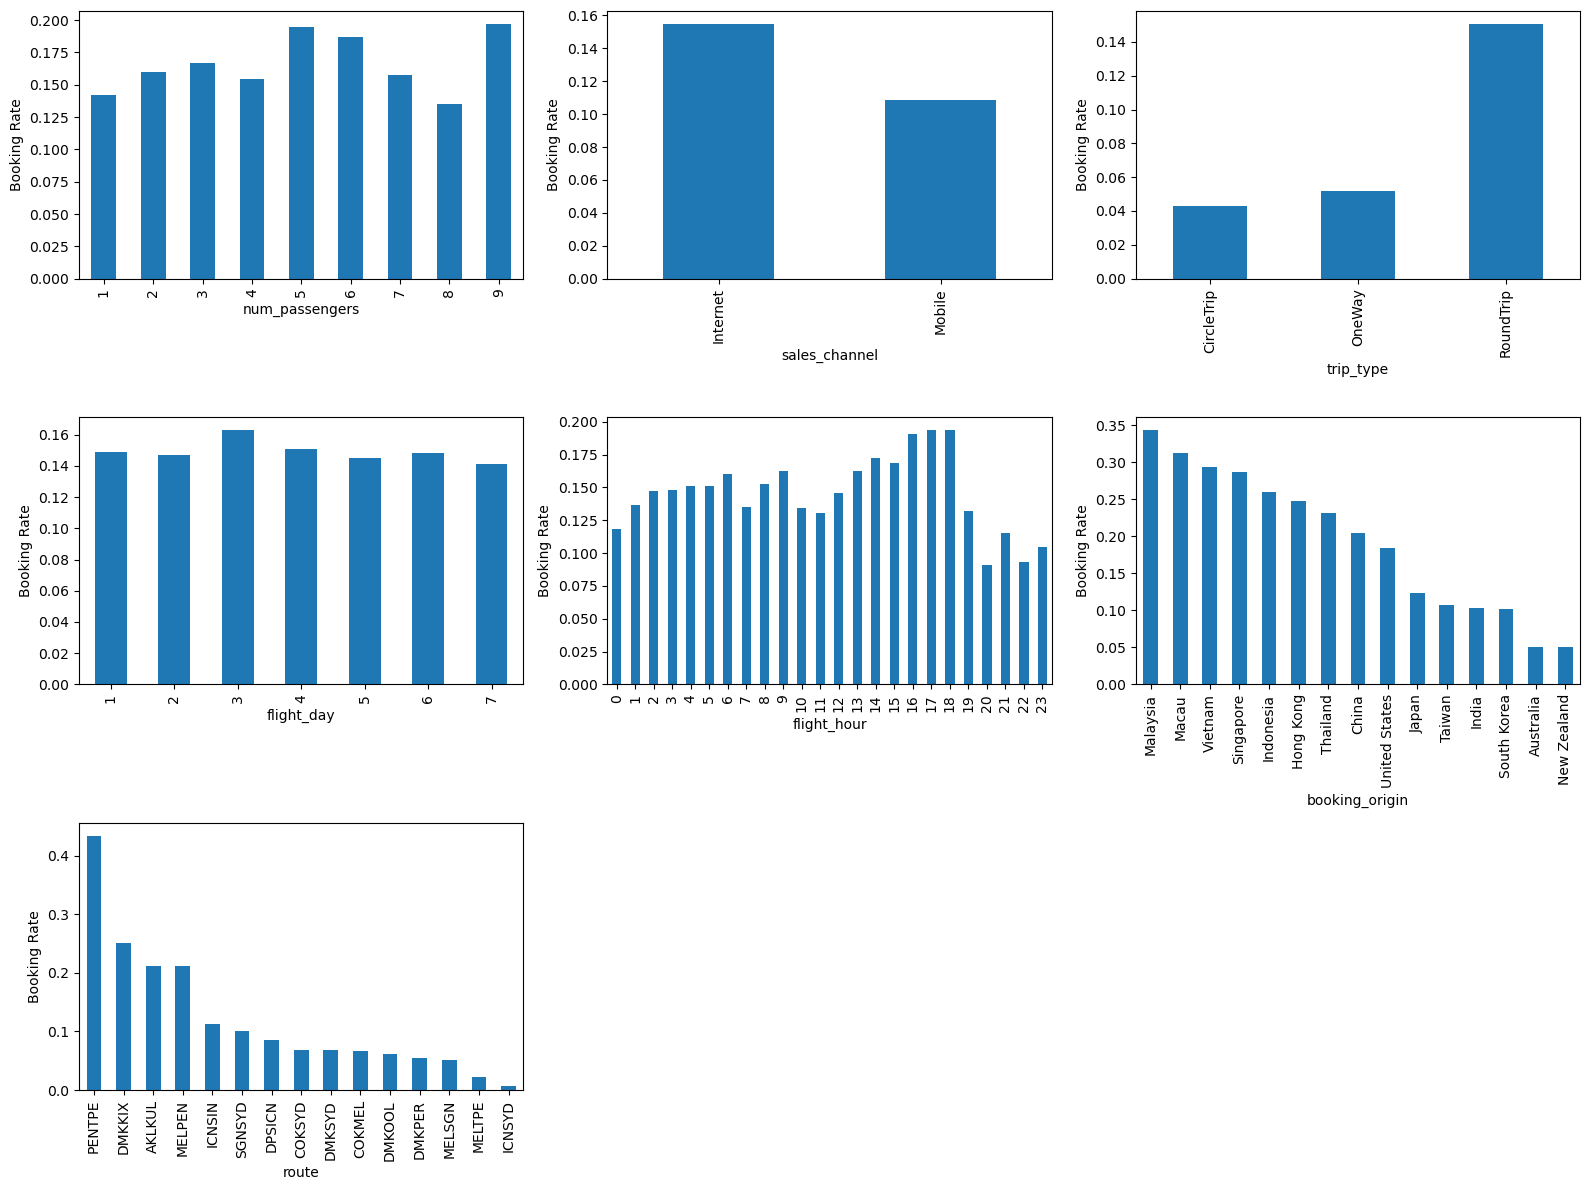

In [40]:
feature_cols = ['num_passengers', 'sales_channel', 'trip_type', 
                'flight_day', 'flight_hour', 
                'booking_origin', 'route']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    
    rate = booking_rate(df1, col)
    
    if col in ['booking_origin', 'route']:
        top_categories = df[col].value_counts().head(15).index
        rate = booking_rate(df1[df1[col].isin(top_categories)], col).sort_values(ascending=False)
    
    rate.plot(kind='bar', ax=axes[i])
    axes[i].set_ylabel('Booking Rate')

for j in range(len(feature_cols), len(axes)):
    axes[j].remove()

plt.tight_layout()
plt.show()

#### Observations
- Internet bookings convert significantly higher than Mobile.
- RoundTrip bookings convert much more than other trip types.
- Evening departure hours show higher booking rates.
- Certain origins (e.g., Malaysia, Singapore) show significantly higher booking rates.
- Specific routes (e.g. PENTPE, DMKKIX) show extremely high conversion rates.

### 2.3 Numerical Binning Analysis
Assess non-linear relationships between continuous features and booking probability.

In [41]:
df1.groupby(pd.qcut(df1['purchase_lead'], 5))['booking_complete'].mean()

/var/folders/qv/wdmv98zx45dg38ty_z5rcg140000gn/T/ipykernel_86718/4225030413.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby(pd.qcut(df1['purchase_lead'], 5))['booking_complete'].mean()


purchase_lead
(-0.001, 17.0]    0.174802
(17.0, 38.0]      0.148458
(38.0, 70.0]      0.149919
(70.0, 141.0]     0.135721
(141.0, 867.0]    0.137415
Name: booking_complete, dtype: float64

In [42]:
df1.groupby(pd.qcut(df1['length_of_stay'], 5))['booking_complete'].mean()

/var/folders/qv/wdmv98zx45dg38ty_z5rcg140000gn/T/ipykernel_86718/4099649045.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby(pd.qcut(df1['length_of_stay'], 5))['booking_complete'].mean()


length_of_stay
(-0.001, 5.0]    0.184323
(5.0, 6.0]       0.207941
(6.0, 20.0]      0.104475
(20.0, 31.0]     0.098158
(31.0, 778.0]    0.120933
Name: booking_complete, dtype: float64

In [43]:
addon_cols = [
    'wants_extra_baggage',
    'wants_preferred_seat',
    'wants_in_flight_meals'
]

for col in addon_cols:
    print(col)
    print(df1.groupby(col)['booking_complete'].mean())

wants_extra_baggage
wants_extra_baggage
0    0.115029
1    0.166662
Name: booking_complete, dtype: float64
wants_preferred_seat
wants_preferred_seat
0    0.137944
1    0.177061
Name: booking_complete, dtype: float64
wants_in_flight_meals
wants_in_flight_meals
0    0.141396
1    0.160509
Name: booking_complete, dtype: float64


In [44]:
df1['addon_sum'] = (
    df1['wants_extra_baggage'] +
    df1['wants_preferred_seat'] +
    df1['wants_in_flight_meals']
)

df1.groupby('addon_sum')['booking_complete'].mean()

addon_sum
0    0.106743
1    0.149594
2    0.159726
3    0.185975
Name: booking_complete, dtype: float64

#### Observations
- Short purchase lead times show higher booking probability.
- Short stays (≤6 days) convert much better.
- Add-on services are positively correlated with conversion. If we combine the three add-on services into a new variable `addon_sum`, we can see that higher values correlate with a higher booking_complete rate.

### 2.4 Correlation Analysis
Detect multicollinearity among numeric variables.

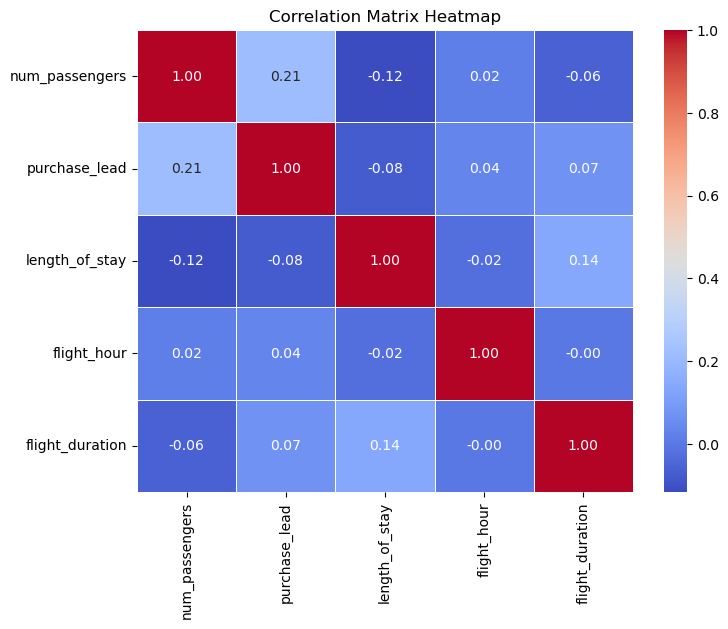

In [45]:
correlation_matrix = df1[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

#### Observations
- Correlations are weak across variables.
- No significant multicollinearity detected.

## 3. Feature Engineering
- Label Encoding: `sales_channel`, `trip_type`, `flight_hour`(first converted into 4 time segments)
- K-Fold Target Encoding: `route`, `booking_origin`

In [46]:
df1['sales_channel'] = df1['sales_channel'].astype('category').cat.codes

In [47]:
df1['trip_type'] = df1['trip_type'].astype('category').cat.codes

In [48]:
df1['hour_bucket'] = pd.cut(
    df1['flight_hour'],
    bins=[0,6,12,18,24],
    labels=False
)

In [49]:
kfold_cols = ['booking_origin', 'route']
target = 'booking_complete'

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in kfold_cols:
    
    df1[col + '_te'] = np.nan
    
    for train_idx, val_idx in kf.split(df1):
        train_data = df1.iloc[train_idx]
        val_data = df1.iloc[val_idx]

        means = train_data.groupby(col)[target].mean()

        df1.loc[val_idx, col + '_te'] = val_data[col].map(means)
        
    overall_means = df1.groupby(col)[target].mean()

## 4. XGBoost Model
XGBoost was selected because it handles non-linear relationships, performs well with heterogeneous features, and is effective for imbalanced datasets. GridSearchCV was used to tune hyperparameters using F1-score as the refit metric.

In [50]:
y = df1['booking_complete']
X = df1.copy().drop(['route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'booking_complete'], axis=1)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [52]:
xgb = XGBClassifier(objective='binary:logistic', scale_pos_weight=0.85/0.15, random_state=42)

cv_params = {
    'max_depth': [3,5,7], 
    'min_child_weight': [1,3,5], 
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [75, 100, 125]
}

scoring = ['accuracy', 'precision', 'recall', 'f1']

xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=3, refit='f1')

In [53]:
%%time
xgb_cv.fit(X_train, y_train)

CPU times: user 3min 52s, sys: 6.08 s, total: 3min 58s
Wall time: 1min 6s


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], 'n_estimators': [75, 100, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'f1'
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


## 5. Model Evaluation

In [54]:
y_pred = xgb_cv.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.71864
Precision: 0.31281235801908225
Recall: 0.7367576243980738
F1: 0.4391644075904959


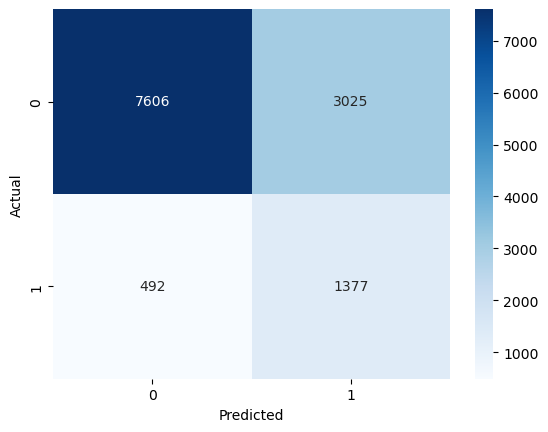

In [55]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [56]:
best_xgb = xgb_cv.best_estimator_

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index()

importance

,index,feature,importance
0,10,booking_origin_te,0.260334
1,11,route_te,0.168132
2,1,sales_channel,0.098095
3,8,addon_sum,0.094663
4,7,flight_duration,0.059882
5,4,length_of_stay,0.057741
6,3,purchase_lead,0.050153
7,0,num_passengers,0.045165
8,9,hour_bucket,0.042549
9,2,trip_type,0.042247


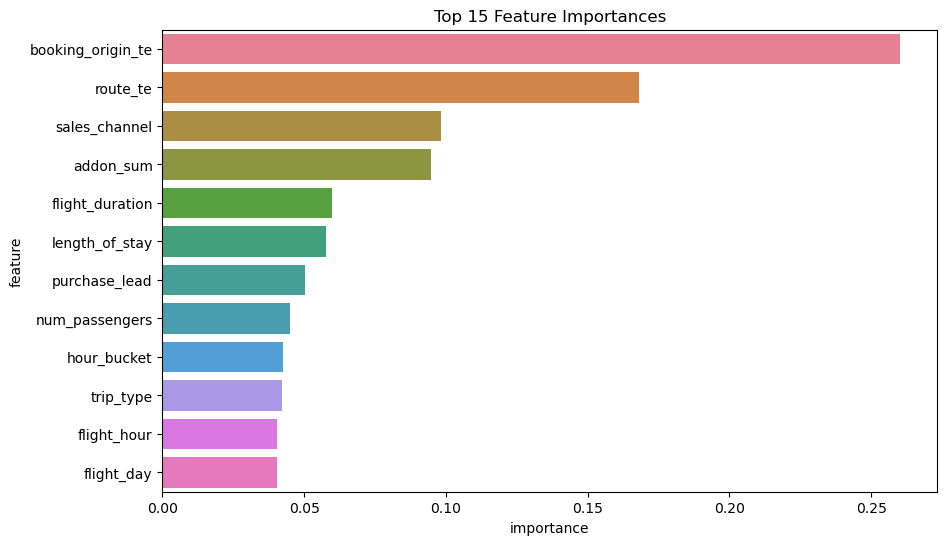

In [57]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(15), 
            x='importance', y='feature', hue='feature')
plt.title('Top 15 Feature Importances')
plt.show()

#### Performance Metrics
- High Recall (0.74): Model successfully identifies most booking customers.
- Low Precision (0.31): Many predicted positives are false positives.
- F1-score (0.44) reflects moderate balance between precision and recall.
- Accuracy (0.72) is not reliable due to class imbalance.

#### Feature Importance
Top drivers are:
- `booking_origin_te`
- `route_te`
- `sales_channel`
- `addon_sum`

## 6. Business Insights & Conclusion
#### Conclusion
This model successfully identifies high-intent customers with strong recall performance. Booking origin and route play a dominant role in predicting booking completion, followed by behavioral indicators such as sales channel and add-on purchases. Although precision remains moderate, the model is effective for identifying potential high-conversion segments.

#### Business Recommendations

1. Allocate marketing budget toward countries/regions with high booking rates (e.g. Malaysia, Macau, Vietnam, Singapore, Indonesia).
2. Focus promotional efforts on high-conversion routes (e.g. PENTPE, DMKKIX, AKLKUL, MELPEN, ICNSIN).
3. Customers booking closer to departure are more likely to convert. Provide time-sensitive offers to short-lead travelers.
5. Internet channel significantly outperforms mobile in conversion rate. Investigate UI/UX differences.